# Matrix Factorisation on IMDB Dataset
Dataset from: [IMDb Users' Ratings Dataset](https://ieee-dataport.org/open-access/imdb-users-ratings-dataset)

In [1]:
# Local packages
from datetime import datetime
import numpy as np

# 3rd party
import imdb
import pandas as pd
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Set up IMDB module which can pull movie titles based on IMDB key
ia = imdb.Cinemagoer()

### Load dataset

In [3]:
dataset = np.load("Dataset/imdb-user-data/Dataset.npy")

### Data preprocessing

In [4]:
# Number of movies, users,
# Proportion of ratings, dates

In [5]:
def convert(date_time):
    # d = day of the month
    # B = full month name
    # Y = full year
    format = '%d %B %Y'
    datetime_str = datetime.strptime(date_time, format)

    return datetime_str

In [6]:
data_dict = {
    'user_id': [data.split(',')[0][2:] for data in dataset],
    'movie_id': [data.split(',')[1][2:] for data in dataset],
    #'movie_title': titles,
    'rating': [int(data.split(',')[2]) for data in dataset],
    'date': [convert(data.split(',')[3]) for data in dataset]
    }
df = pd.DataFrame(data_dict)

In [7]:
# clear memory
data_dict={}

In [8]:
df.head()

,user_id,movie_id,rating,date
0,4592644,0120884,10,2005-01-16
1,3174947,0118688,3,2005-01-16
2,3780035,0387887,8,2005-01-16
3,4592628,0346491,1,2005-01-16
4,3174947,0094721,8,2005-01-16


### EDA

In [9]:
movies = df['movie_id'].value_counts()
movies

movie_id
7286456    10534
4154796     8835
8110330     7729
0111161     7568
2527338     7547
           ...  
1288493        1
1411870        1
3351428        1
0387011        1
0396641        1
Name: count, Length: 351109, dtype: int64

In [10]:
users = df['user_id'].value_counts()
users

user_id
2467618     24145
20552756    16817
2483625     16715
0482513     13213
2898520     12677
            ...  
57985005        1
22259590        1
58035808        1
58063141        1
4592639         1
Name: count, Length: 1499238, dtype: int64

<Axes: xlabel='Rating', ylabel='Count'>

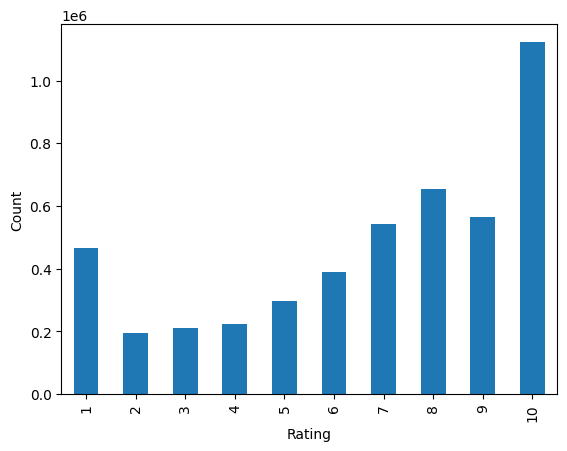

In [11]:
df.rating.value_counts().sort_index().plot(kind="bar", xlabel="Rating", ylabel="Count")

<Axes: xlabel='date'>

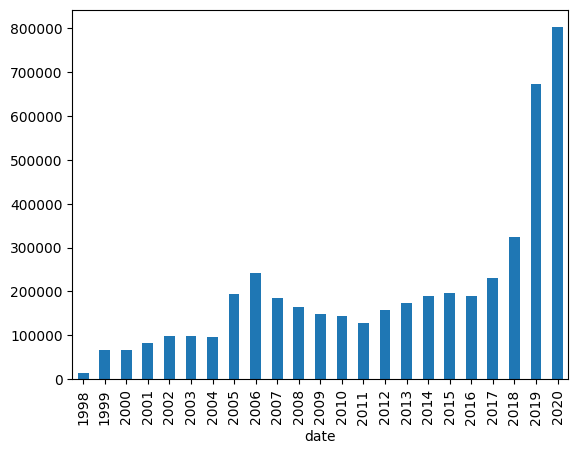

In [12]:
df["date"].groupby(df["date"].dt.year).count().plot(kind="bar")

In [13]:
dates = df["date"].value_counts()
dates

date
2019-05-20    7291
2020-07-25    5773
2020-07-24    4542
2020-11-21    4045
2019-05-13    3788
              ... 
1998-08-25       7
1998-08-27       6
1998-07-27       3
2002-01-01       2
2018-04-30       1
Name: count, Length: 8028, dtype: int64

### Matrix Factorisation
Using:
- SKLearn NMF (Non-Negative Matrix Factorisation) algorithm [[1](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)]
- Code from [[2](https://github.com/dinesh-git17/movie_recommendation/tree/main)]

In [14]:
# TODO - change to use movie titles not ids once that's working

def create_pivot_table(data, min_ratings=100):
    """
    Creates a pivot table (users x movies) with ratings.
    Only movies with at least min_ratings are retained.

    Arguments:
        data (): TBC
        min_ratings (int): TBC
    Returns:
        TBC
    """
    # Count number of ratings per movie
    ratings_count = data.groupby("movie_id")["rating"].count()
    popular_movies = ratings_count[ratings_count >= min_ratings].index
    filtered_data = data[data["movie_id"].isin(popular_movies)]

    # Create pivot table: rows = user_id, columns = movie_id, values = rating
    pivot = filtered_data.pivot_table(index="user_id", columns="movie_id", values="rating")
    return pivot

def NMF_recommendations(movie_id, pivot, n_components=20, top_n=10):
    """
    Generates recommendations using NMF-based matrix factorization
    Fills missing ratings with 0, factorizes the matrix, and computes cosine similarities
    on the movie latent factors.

    Arguments:
        TBC
    Returns:
        recommendations (): top_n recommendations based on similarity to movie_id
    """
    # Fill missing values with 0
    pivot_filled = pivot.fillna(0)

    # Apply NMF to factorize the matrix into user and movie latent factors
    nmf_model = NMF(n_components=n_components, init="random", random_state=42)
    W = nmf_model.fit_transform(pivot_filled)
    H = nmf_model.components_  # shape: (n_components, n_movies)

    # Transpose H to get movie latent factors: shape (n_movies, n_components)
    movie_factors = H.T
    movie_ids = pivot_filled.columns.tolist()

    # Compute cosine similarity between movies using the latent factors
    similarity_matrix = cosine_similarity(movie_factors)
    similarity_df = pd.DataFrame(
        similarity_matrix, index=movie_ids, columns=movie_ids
    )

    if movie_id not in similarity_df.index:
        raise ValueError(f"Movie '{movie_id}' not found in the dataset.")

    # Get the similarity series for the given movie and sort descending
    similar_movies = (
        similarity_df[movie_id]
        .drop(labels=[movie_id])
        .sort_values(ascending=False)
    )
    recommendations = similar_movies.head(top_n)
    return recommendations

In [15]:
pivot_table = create_pivot_table(df[0:120000])
pivot_table.head()

movie_id,0110912,0111161,0120338,0120667,0121766,0167260,0246578,0257516,0290002,0293508,...,0403508,0405159,0405422,0407304,0412019,0417001,0418819,0421239,0430105,0435625
user_id,,,,,,,,,,,,,,,,,,,,,
0000066,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN
0000752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0002420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0002746,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0002840,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
movie_id = "0246578"

In [17]:
recs = NMF_recommendations(movie_id, pivot_table)
recs

0377109    0.988539
0257516    0.983647
0369226    0.983016
0384806    0.982438
0338095    0.980936
0395584    0.980282
0418819    0.980223
0373074    0.980223
0397065    0.971194
0382077    0.961503
Name: 0246578, dtype: float64

In [ ]:
recs = [ia.get_movie(rec)["title"] for rec in recs.keys()]
recs

['The Ring Two',
 'Cursed',
 'Alone in the Dark',
 'The Amityville Horror',
 'High Tension',
 "The Devil's Rejects",
 'Land of the Dead',
 'Kung Fu Hustle',
 'House of Wax',
 'Hide and Seek']

In [19]:
print(f"Recommendations similar to: {ia.get_movie(movie_id)['title']}")
print(recs)

Recommendations similar to: Donnie Darko
['The Ring Two', 'Cursed', 'Alone in the Dark', 'The Amityville Horror', 'High Tension', "The Devil's Rejects", 'Land of the Dead', 'Kung Fu Hustle', 'House of Wax', 'Hide and Seek']
